# **PISA STUDENTS**

## Imports

In [1]:
import numpy as np
import pandas as pd
import os
from sklearn.model_selection import train_test_split
from models import train_linear_model, train_logistic_model
from sklearn.metrics import accuracy_score
from data import category_split, balance_feature, frame_status_info
from evaluation import evaluate_model, plot_model_acc_and_fscore, display_model_weights, evaluate_model_thresholded_regression, evaluate_model_classifier

Using device: cpu


## Settings

In [2]:
DATA_RELATIVE_PATH = "data/pisa_2022/pisa_clean.csv"

TARGET_COLUMN = "GENERAL_SCORE"
TARGET_OPERTOR = "<" #Does not change the training, only splits
TARGET_VALUE = 400 #This value will be changed in a future cell
PERCENTILE = 10


RANDOM_SEED = None
SPLIT_PERCENTAGE_TESTING = 0.15

BALANCE_DATA = False
BALANCE_QUERY = TARGET_COLUMN + " " + TARGET_OPERTOR + " " + str(TARGET_VALUE) #This value is updated in future cell
BALANCE_QUERY_NON_TARGET_PERCENTAGE = 0.50

MODEL_BALANCE = True
BALANCE = "balanced" if MODEL_BALANCE else None


REGULARIZER_WEIGTH = 0.1
#MODEL_THERESHOLD_REG = TARGET_VALUE
MODEL_THERESHOLD_LOG = 0.5

DEBUG_MODE = True


## Loading the Data

In [3]:
# Load dataset
data_file = os.path.join(os.getcwd(), DATA_RELATIVE_PATH)
df = pd.read_csv(data_file)
print("Loaded datafile")
print(df.shape)

Loaded datafile
(6072, 521)


# Data processing

### Irrelevant data

In [4]:
#Remove constant columns
df = df.loc[:, df.nunique() > 1]
print(df.shape)

(6072, 520)


### Identical Data

In [5]:
# Ensure all rows are unique
df = df.drop_duplicates()
print("Removed duplicate rows")
print(df.shape)

Removed duplicate rows
(6072, 520)


### Missing data

In [6]:
# Investigation
# Count missing values per column
missing_counts = df.isnull().sum()

# Total number of rows
total_rows = len(df)

# Create summary DataFrame
missing_summary = pd.DataFrame({
    'Missing Count': missing_counts,
    'Missing Percent': (missing_counts / total_rows * 100).round(2)
})

# Filter to only show columns with missing data
missing_summary = missing_summary[missing_summary['Missing Count'] > 0]

# Sort by most missing values
missing_summary = missing_summary.sort_values(by='Missing Percent', ascending=False)

# Display result
print(missing_summary.head(120))  # Show top 20, adjust as needed

Empty DataFrame
Columns: [Missing Count, Missing Percent]
Index: []


In [7]:
# All data is present in this dataframe.
# Fill NaN values in numeric columns with the column mean
df = df.apply(lambda col: col.fillna(col.mean()) if pd.api.types.is_numeric_dtype(col) else col)
print(df.shape)

(6072, 520)


### Data transformation

In [8]:
# Round all float columns to 2 decimal places
df = df.apply(lambda col: col.round(2) if pd.api.types.is_float_dtype(col) else col)
print(df.shape)

(6072, 520)


### POST REMOVAL

In [9]:
print(df.shape)

(6072, 520)


## Feature Processing

### Columns to be removed

In [10]:
#Remove columns
#columns_to_remove = ["CNTSTUID", "ST004D01T", "AGE", "SCIENCE_AVG", "MATH_AVG", "READING_AVG", "ST251D08JA", "OCOD1", "OCOD2", "OCOD3", "PROGN", "ISCEDP", "COBN_S", "COBN_M", "COBN_F", "LANGN"]
#df.drop(columns=columns_to_remove, inplace=True, errors='ignore')
print(df.shape)

(6072, 520)


### Prediction column analysis

In [25]:
# Calculate the score corresponding to that percentile
PERCENTILE = 36  # Change this to the desired percentile (e.g., 10 for the 10th percentile)
THRESHOLD_SCORE = df['GENERAL_SCORE'].quantile(PERCENTILE / 100)

print(f"{PERCENTILE}th percentile score: {THRESHOLD_SCORE:.2f}")

# Optionally: Filter students at or below that percentile
lowest_students = df[df['GENERAL_SCORE'] <= THRESHOLD_SCORE]

print(f"Number of students at or below the {PERCENTILE}th percentile: {len(lowest_students)}")
print(lowest_students[['GENERAL_SCORE']].head())

TARGET_VALUE = THRESHOLD_SCORE
BALANCE_QUERY = TARGET_COLUMN + " " + TARGET_OPERTOR + " " + str(TARGET_VALUE)

36th percentile score: 452.16
Number of students at or below the 36th percentile: 2186
    GENERAL_SCORE
0          377.28
4          371.74
10         444.80
11         419.16
17         433.53


## Splitting data

### Split

In [12]:
train_df, test_df = train_test_split(df, test_size=SPLIT_PERCENTAGE_TESTING, random_state=RANDOM_SEED)
frame_status_info(train_df, test_df)

Training data shape: (5161, 520)
Testing data shape: (911, 520)


### Balance

In [13]:
if (BALANCE_DATA):
    match_df, no_match_df = category_split(train_df, BALANCE_QUERY)
    train_balanced = balance_feature(match_df, no_match_df, BALANCE_QUERY_NON_TARGET_PERCENTAGE)

## Training

### Preparation

In [14]:
# Define features and target variable
temp_train : pd.DataFrame = train_balanced if BALANCE_DATA else train_df

frame_status_info(temp_train, test_df)
print("Training percentage:", test_df.shape[0]/(temp_train.shape[0]+test_df.shape[0]))

X_train = temp_train.drop(columns=[TARGET_COLUMN]).values
y_train_reg = temp_train[TARGET_COLUMN]
y_train_cls = (temp_train[TARGET_COLUMN] < TARGET_VALUE).astype(int)

X_test = test_df.drop(columns=[TARGET_COLUMN]).values
y_test_reg = test_df[TARGET_COLUMN]
y_test_cls = (test_df[TARGET_COLUMN] < TARGET_VALUE).astype(int)

Training data shape: (5161, 520)
Testing data shape: (911, 520)
Training percentage: 0.15003293807641635


### Execution

In [15]:
# Train regression models
print("Training RegN")
model_reg_no = train_linear_model(X_train, y_train_reg.values, reg_type=None)  # Standard
print("Training Reg1")
model_reg_l1 = train_linear_model(X_train, y_train_reg.values, reg_type="l1", alpha=REGULARIZER_WEIGTH)  # Lasso
print("Training Reg2")
model_reg_l2 = train_linear_model(X_train, y_train_reg.values, reg_type="l2", alpha=REGULARIZER_WEIGTH)  # Ridge

# Train logistic models
print("Training LogN")
model_log_no = train_logistic_model(X_train, y_train_cls.values, reg_type=None, class_weight=BALANCE)  # Standard
print("Training Log1")
model_log_l1 = train_logistic_model(X_train, y_train_cls.values, reg_type="l1", alpha=REGULARIZER_WEIGTH, class_weight=BALANCE)  # Lasso
print("Training Log2")
model_log_l2 = train_logistic_model(X_train, y_train_cls.values, reg_type="l2", alpha=REGULARIZER_WEIGTH, class_weight=BALANCE)  # Ridge

Training RegN
Training Reg1


c:\Users\jonat\anaconda3\envs\student_performance_env\Lib\site-packages\sklearn\linear_model\_stochastic_gradient.py:1608: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(


Training Reg2


c:\Users\jonat\anaconda3\envs\student_performance_env\Lib\site-packages\sklearn\linear_model\_stochastic_gradient.py:1608: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(


Training LogN
Training Log1
Training Log2


## Evaluation

### Execution

Regression Models:
[Standard Linear Regression] Sample predicted scores: [1.97628359e+12 1.03458533e+12 1.83384123e+12 4.93358057e+11
 1.18338492e+12 9.44758809e+11 4.55683338e+11 1.82756590e+12
 6.83380809e+10 9.04407538e+11]
[Standard Linear Regression] Applied threshold: 357.314
[Standard Linear Regression] Predicted labels: [False False False False False False False False False False]
[Standard Linear Regression] Sample true values: [1 0 0 0 0 0 0 0 0 0]
[Standard Linear Regression] Accuracy: 0.610318331503842
[Standard Linear Regression] F1 Score: 0.14457831325301204


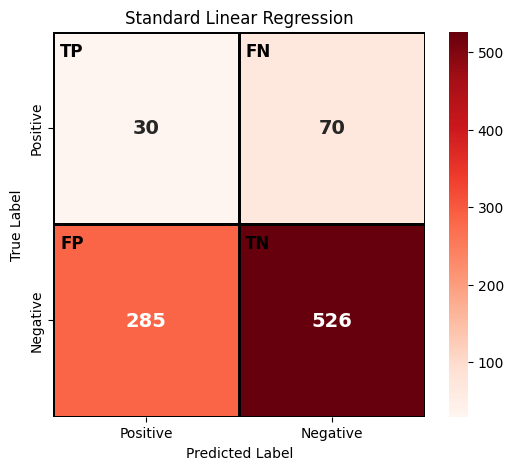

[Lasso Regression] Sample predicted scores: [2.57132192e+12 2.41182823e+12 1.65382952e+12 8.31455295e+11
 2.96035909e+12 1.79286608e+12 2.12903372e+12 8.08293396e+11
 1.83715659e+12 2.14983204e+12]
[Lasso Regression] Applied threshold: 357.314
[Lasso Regression] Predicted labels: [False False False False False False False False False False]
[Lasso Regression] Sample true values: [1 0 0 0 0 0 0 0 0 0]
[Lasso Regression] Accuracy: 0.8902305159165752
[Lasso Regression] F1 Score: 0


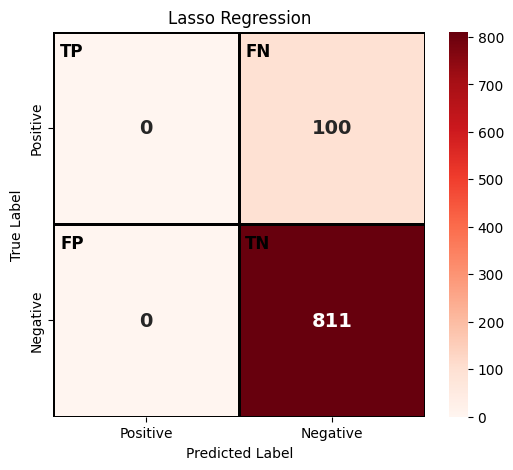

[Ridge Regression] Sample predicted scores: [-1395407.11072793  -720909.18070616  -869826.12510038 -3172231.21647795
 -1220926.76820267 -5717591.62294856 -1300525.55215078 -2346016.83287693
  -110258.3695706  -3093533.70797673]
[Ridge Regression] Applied threshold: 357.314
[Ridge Regression] Predicted labels: [ True  True  True  True  True  True  True  True  True  True]
[Ridge Regression] Sample true values: [1 0 0 0 0 0 0 0 0 0]
[Ridge Regression] Accuracy: 0.3534577387486279
[Ridge Regression] F1 Score: 0.21571238348868177


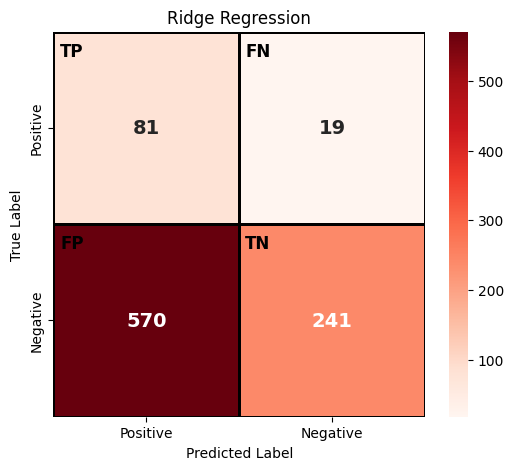

Logistic Models:
[Standard Logistic Regression] Sample predicted probabilities: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
[Standard Logistic Regression] Applied threshold: 0.5
[Standard Logistic Regression] Predicted labels: [False False False False False False False False False False]
[Standard Logistic Regression] Sample true values: [1 0 0 0 0 0 0 0 0 0]
[Standard Logistic Regression] Accuracy: 0.8902305159165752
[Standard Logistic Regression] F1 Score: 0


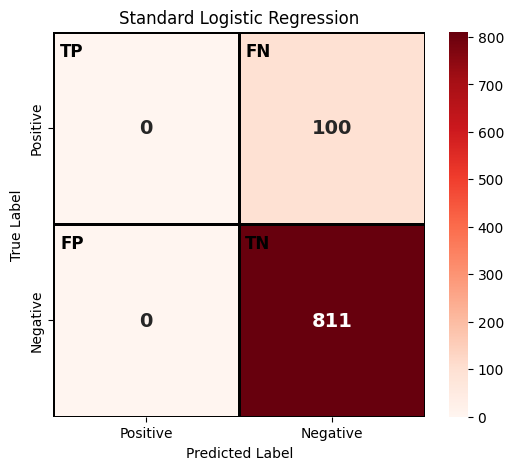

[Lasso Logistic Regression] Sample predicted probabilities: [0.38064602 0.22358504 0.13210247 0.24172865 0.12474259 0.13627308
 0.19229602 0.15700695 0.13115461 0.15267034]
[Lasso Logistic Regression] Applied threshold: 0.5
[Lasso Logistic Regression] Predicted labels: [False False False False False False False False False False]
[Lasso Logistic Regression] Sample true values: [1 0 0 0 0 0 0 0 0 0]
[Lasso Logistic Regression] Accuracy: 0.8902305159165752
[Lasso Logistic Regression] F1 Score: 0


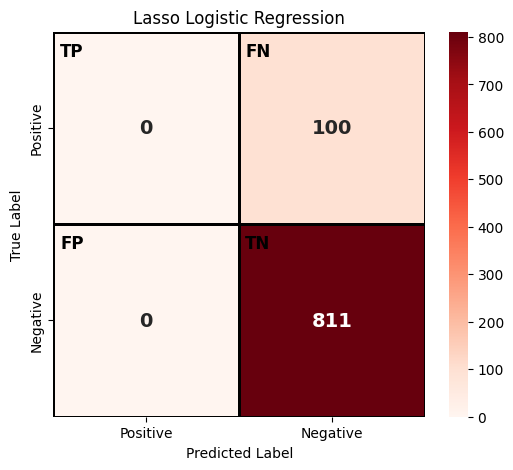

[Ridge Logistic Regression] Sample predicted probabilities: [2.95125252e-02 3.62550533e-02 5.73324661e-05 3.07090211e-03
 7.15685614e-05 2.43498654e-04 9.83329525e-05 9.32615493e-06
 2.19638127e-04 5.71845193e-06]
[Ridge Logistic Regression] Applied threshold: 0.5
[Ridge Logistic Regression] Predicted labels: [False False False False False False False False False False]
[Ridge Logistic Regression] Sample true values: [1 0 0 0 0 0 0 0 0 0]
[Ridge Logistic Regression] Accuracy: 0.889132821075741
[Ridge Logistic Regression] F1 Score: 0


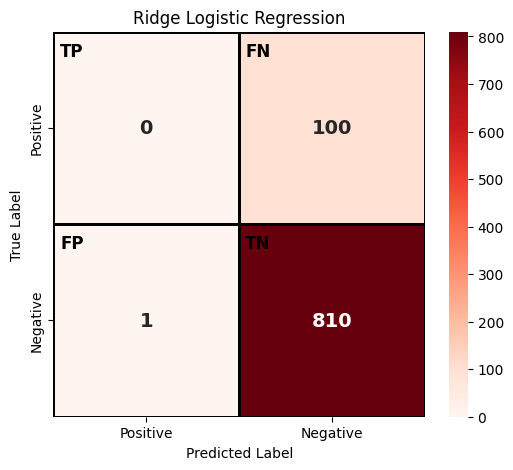

In [16]:
# Evaluate regression models
print("Regression Models:")
acc_reg_no, f_reg_no = evaluate_model_thresholded_regression(model_reg_no, X_test, (y_test_reg < TARGET_VALUE).astype(int), TARGET_VALUE, "Standard Linear Regression", debug=DEBUG_MODE)
acc_reg_l1, f_reg_l1 = evaluate_model_thresholded_regression(model_reg_l1, X_test, (y_test_reg < TARGET_VALUE).astype(int), TARGET_VALUE, "Lasso Regression", debug=DEBUG_MODE)
acc_reg_l2, f_reg_l2 = evaluate_model_thresholded_regression(model_reg_l2, X_test, (y_test_reg < TARGET_VALUE).astype(int), TARGET_VALUE, "Ridge Regression", debug=DEBUG_MODE)

# Evaluate logistic models
print("Logistic Models:")
acc_log_no, f_log_no = evaluate_model_classifier(model_log_no, X_test, y_test_cls, MODEL_THERESHOLD_LOG, "Standard Logistic Regression", debug=DEBUG_MODE)
acc_log_l1, f_log_l1 = evaluate_model_classifier(model_log_l1, X_test, y_test_cls, MODEL_THERESHOLD_LOG, "Lasso Logistic Regression", debug=DEBUG_MODE)
acc_log_l2, f_log_l2 = evaluate_model_classifier(model_log_l2, X_test, y_test_cls, MODEL_THERESHOLD_LOG, "Ridge Logistic Regression", debug=DEBUG_MODE)

### Analysis

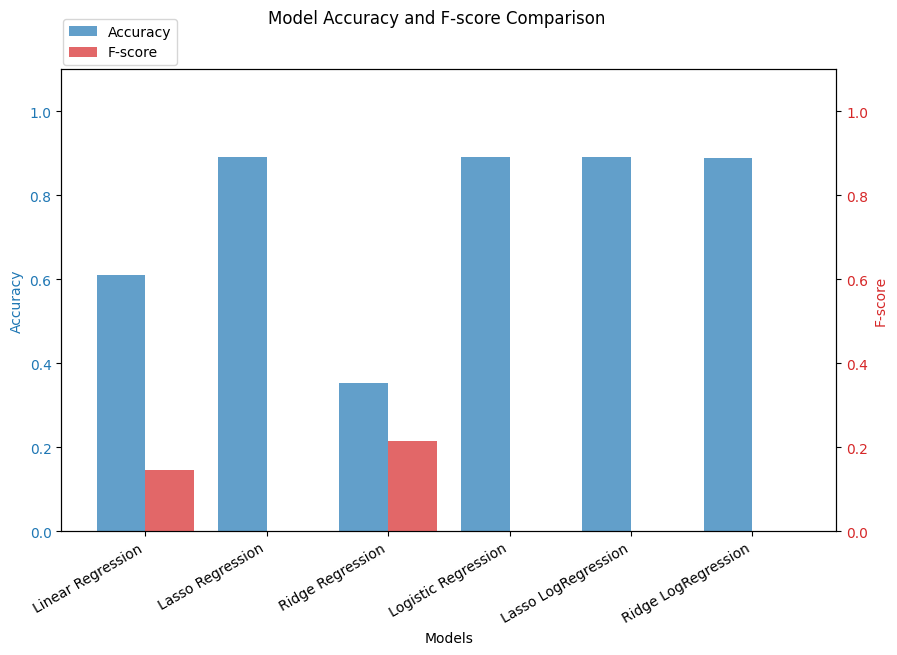

In [17]:
accs = [acc_reg_no, acc_reg_l1, acc_reg_l2, acc_log_no, acc_log_l1, acc_log_l2]
fscores = [f_reg_no, f_reg_l1, f_reg_l2, f_log_no, f_log_l1, f_log_l2]
model_names = ["Linear Regression", "Lasso Regression", "Ridge Regression",
               "Logistic Regression", "Lasso LogRegression", "Ridge LogRegression"]
plot_model_acc_and_fscore(accs, fscores, model_names)

### Weights

In [18]:
display_model_weights(model_reg_no, train_df.drop(columns=[TARGET_COLUMN]), num_features=10)

          Feature  Absolute value weight        Weight
101    ST273Q06JA           1.661776e+11  1.661776e+11
404  ST038Q08NA_4           1.653445e+11  1.653445e+11
376  ST062Q02TA_4           1.508173e+11  1.508173e+11
334        MISSSC           1.482583e+11 -1.482583e+11
395  ST038Q06NA_3           1.450457e+11  1.450457e+11
367  ST260Q03JA_2           1.371449e+11 -1.371449e+11
176    ST289Q05WA           1.344504e+11  1.344504e+11
142    ST276Q09JA           1.312229e+11 -1.312229e+11
338       WORKPAY           1.276168e+11 -1.276168e+11
375  ST062Q02TA_3           1.189411e+11 -1.189411e+11
Displayed sorted feature weights


In [19]:
display_model_weights(model_reg_l1, train_df.drop(columns=[TARGET_COLUMN]), num_features=10)

          Feature  Absolute value weight        Weight
339      WORKHOME           3.736012e+11 -3.736012e+11
337      STUDYHMW           2.351106e+11 -2.351106e+11
67     ST294Q03JA           2.276955e+11  2.276955e+11
72     ST295Q03JA           1.877483e+11  1.877483e+11
66     ST294Q02JA           1.629677e+11  1.629677e+11
71     ST295Q02JA           1.199911e+11  1.199911e+11
334        MISSSC           1.061006e+11 -1.061006e+11
335      SKIPPING           9.413449e+10 -9.413449e+10
373  ST062Q02TA_1           4.296137e+10 -4.296137e+10
338       WORKPAY           4.266560e+10 -4.266560e+10
Displayed sorted feature weights


In [20]:
display_model_weights(model_reg_l2, train_df.drop(columns=[TARGET_COLUMN]), num_features=10)

        Feature  Absolute value weight        Weight
337    STUDYHMW           1.735155e+06  1.735155e+06
339    WORKHOME           1.480282e+06 -1.480282e+06
66   ST294Q02JA           1.197250e+06 -1.197250e+06
67   ST294Q03JA           1.042452e+06  1.042452e+06
71   ST295Q02JA           8.219261e+05 -8.219261e+05
72   ST295Q03JA           5.674690e+05  5.674690e+05
335    SKIPPING           2.596396e+05  2.596396e+05
338     WORKPAY           1.926380e+05  1.926380e+05
334      MISSSC           1.458948e+05 -1.458948e+05
73   ST295Q04JA           1.099153e+05 -1.099153e+05
Displayed sorted feature weights


In [21]:
display_model_weights(model_reg_no, train_df.drop(columns=[TARGET_COLUMN]), num_features=10)

          Feature  Absolute value weight        Weight
101    ST273Q06JA           1.661776e+11  1.661776e+11
404  ST038Q08NA_4           1.653445e+11  1.653445e+11
376  ST062Q02TA_4           1.508173e+11  1.508173e+11
334        MISSSC           1.482583e+11 -1.482583e+11
395  ST038Q06NA_3           1.450457e+11  1.450457e+11
367  ST260Q03JA_2           1.371449e+11 -1.371449e+11
176    ST289Q05WA           1.344504e+11  1.344504e+11
142    ST276Q09JA           1.312229e+11 -1.312229e+11
338       WORKPAY           1.276168e+11 -1.276168e+11
375  ST062Q02TA_3           1.189411e+11 -1.189411e+11
Displayed sorted feature weights


In [22]:
display_model_weights(model_log_l1, train_df.drop(columns=[TARGET_COLUMN]), num_features=10)

          Feature  Absolute value weight    Weight
11     ST253Q01JA               0.234457 -0.234457
204    ST297Q09JA               0.101670 -0.101670
39     ST019BQ01T               0.065770  0.065770
8      ST251Q04JA               0.044192 -0.044192
41     ST022Q01TA               0.033140  0.033140
376  ST062Q02TA_4               0.029499  0.029499
503  IC181Q02JA_2               0.000000  0.000000
502  IC181Q02JA_1               0.000000  0.000000
7      ST251Q03JA               0.000000  0.000000
518     TARDYSD_2               0.000000  0.000000
Displayed sorted feature weights


In [23]:
display_model_weights(model_log_l2, train_df.drop(columns=[TARGET_COLUMN]), num_features=10)

        Feature  Absolute value weight    Weight
204  ST297Q09JA               0.201672 -0.201672
11   ST253Q01JA               0.195265 -0.195265
80   ST326Q06JA               0.177021  0.177021
79   ST326Q05JA               0.159458 -0.159458
75   ST326Q01JA               0.151683 -0.151683
246  IC171Q06JA               0.148854  0.148854
237  IC170Q04JA               0.146088 -0.146088
18   ST255Q01JA               0.144292 -0.144292
14   ST254Q03JA               0.143656 -0.143656
72   ST295Q03JA               0.142339 -0.142339
Displayed sorted feature weights
